<a href="https://colab.research.google.com/github/yuhui-0611/SEED/blob/main/SEED_YB_%EB%8D%B0%EC%9D%B4%ED%84%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 전체_통합.xlsx to 전체_통합.xlsx


In [ ]:
import pandas as pd
df = pd.read_excel('전체_통합.xlsx', engine='openpyxl')

In [ ]:
df.head()

,행정구역,연도_분기,전체점포수,프랜차이즈 점포수,일반 점포수,개업률,폐업률,1년 생존율,3년 생존율,5년 생존율,log인구,인구(raw),환산임대료,10년영업기간,30년영업기간,실업률,소비자심리지수(평균),소득분위
0,서울시 전체,2015-Q1,571434,38561,532873,3.1,3.9,75.0,51.1,36.8,7.015740,10369067,96760,3.6,5.3,4.07,102.966667,7
1,종로구,2015-Q1,25276,1306,23970,2.5,3.4,80.0,57.0,42.2,5.218115,165240,151285,3.8,6.1,4.07,102.966667,7
2,중구,2015-Q1,43310,1642,41668,2.7,3.7,81.2,59.5,44.1,5.133740,136063,191889,4.0,6.0,4.07,102.966667,7
3,용산구,2015-Q1,18912,969,17943,2.9,3.6,78.8,56.3,41.7,5.397945,250003,95330,3.8,5.5,4.07,102.966667,8
4,성동구,2015-Q1,15655,1030,14625,3.2,3.7,77.8,55.3,40.2,5.482555,303777,76623,3.7,5.6,4.07,102.966667,7


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040 entries, 0 to 1039
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   행정구역         1040 non-null   object 
 1   연도_분기        1040 non-null   object 
 2   전체점포수        1040 non-null   int64  
 3   프랜차이즈 점포수    1040 non-null   int64  
 4   일반 점포수       1040 non-null   int64  
 5   개업률          1040 non-null   float64
 6   폐업률          1040 non-null   float64
 7   1년 생존율       1040 non-null   float64
 8   3년 생존율       1040 non-null   float64
 9   5년 생존율       1040 non-null   float64
 10  log인구        1040 non-null   float64
 11  인구(raw)      1040 non-null   int64  
 12  환산임대료        1040 non-null   int64  
 13  10년영업기간      1040 non-null   float64
 14  30년영업기간      1040 non-null   float64
 15  실업률          1040 non-null   float64
 16  소비자심리지수(평균)  1040 non-null   float64
 17  소득분위         1040 non-null   int64  
dtypes: float64(10), int64(6), object(2)
memory usage

In [ ]:
# 3년 생존율, 인구(raw) 변수 삭제
df = df.drop(['3년 생존율', '인구(raw)'], axis=1)

In [ ]:
import pandas as pd

# 1. '연도_분기' → '연도-월-01'로 변환
quarter_to_month = {
    'Q1': '01',
    'Q2': '04',
    'Q3': '07',
    'Q4': '10'
}

df['연도_분기_날짜'] = df['연도_분기'].apply(lambda x: f"{x[:4]}-{quarter_to_month[x[-2:]]}-01")
df['연도_분기_날짜'] = pd.to_datetime(df['연도_분기_날짜'])

# 2. 원래 데이터 순서를 저장할 'original_index' 컬럼 추가
df['original_index'] = df.index

# 3. '연도_분기'와 '행정구역'에 대해 정렬
df = df.sort_values(by=['행정구역', '연도_분기_날짜'])

# 4. 차분 계산 (행정구역별로)
df['1년 생존율_차분'] = df.groupby('행정구역')['1년 생존율'].diff()
df['5년 생존율_차분'] = df.groupby('행정구역')['5년 생존율'].diff()

# 5. 차분 후 원래 순서로 복원
df_reset = df.sort_values(by=['original_index']).reset_index(drop=True)

# 결과 확인
print(df_reset[['연도_분기', '행정구역', '1년 생존율_차분', '5년 생존율_차분']])

        연도_분기    행정구역  1년 생존율_차분  5년 생존율_차분
0     2015-Q1  서울시 전체        NaN        NaN
1     2015-Q1     종로구        NaN        NaN
2     2015-Q1      중구        NaN        NaN
3     2015-Q1     용산구        NaN        NaN
4     2015-Q1     성동구        NaN        NaN
...       ...     ...        ...        ...
1035  2024-Q4     관악구        0.0       -0.2
1036  2024-Q4     서초구        0.0       -0.2
1037  2024-Q4     강남구        0.0       -0.3
1038  2024-Q4     송파구        0.0       -0.2
1039  2024-Q4     강동구        0.0       -0.2

[1040 rows x 4 columns]


In [ ]:
df = df_reset
df = df.drop(['original_index'], axis=1)
df.head()

,행정구역,연도_분기,전체점포수,프랜차이즈 점포수,일반 점포수,개업률,폐업률,1년 생존율,5년 생존율,log인구,환산임대료,10년영업기간,30년영업기간,실업률,소비자심리지수(평균),소득분위,연도_분기_날짜,1년 생존율_차분,5년 생존율_차분,프랜차이즈비율
0,서울시 전체,2015-Q1,571434,38561,532873,3.1,3.9,75.0,36.8,7.015740,96760,3.6,5.3,4.07,102.966667,7,2015-01-01,NaN,NaN,0.067481
1,종로구,2015-Q1,25276,1306,23970,2.5,3.4,80.0,42.2,5.218115,151285,3.8,6.1,4.07,102.966667,7,2015-01-01,NaN,NaN,0.051670
2,중구,2015-Q1,43310,1642,41668,2.7,3.7,81.2,44.1,5.133740,191889,4.0,6.0,4.07,102.966667,7,2015-01-01,NaN,NaN,0.037913
3,용산구,2015-Q1,18912,969,17943,2.9,3.6,78.8,41.7,5.397945,95330,3.8,5.5,4.07,102.966667,8,2015-01-01,NaN,NaN,0.051237
4,성동구,2015-Q1,15655,1030,14625,3.2,3.7,77.8,40.2,5.482555,76623,3.7,5.6,4.07,102.966667,7,2015-01-01,NaN,NaN,0.065794


---
## [1] 변수 선택

In [ ]:
df[['실업률', '소비자심리지수(평균)']].corr()

,실업률,소비자심리지수(평균)
실업률,1.000000,-0.011537
소비자심리지수(평균),-0.011537,1.000000


-> 실업률과 소비자심리지수(평균)은 거의 상관없는 데이터들이라 함께 사용 가능 할듯

In [ ]:
data = df.drop(['행정구역','연도_분기'], axis=1)

In [ ]:
data.corr()

,전체점포수,프랜차이즈 점포수,일반 점포수,개업률,폐업률,1년 생존율,5년 생존율,log인구,환산임대료,10년영업기간,30년영업기간,실업률,소비자심리지수(평균),소득분위,연도_분기_날짜,original_index,1년 생존율_차분,5년 생존율_차분
전체점포수,1.000000,0.995666,0.999968,-0.025883,-0.046070,0.039073,0.047506,0.865187,0.100286,0.012787,0.013575,-0.014622,-0.006474,0.039564,0.021505,0.013980,-0.000284,-0.000957
프랜차이즈 점포수,0.995666,1.000000,0.994888,-0.018881,-0.053224,0.043419,0.058231,0.872456,0.083430,-0.005984,-0.014770,-0.025591,-0.019146,0.029038,0.050994,0.043849,0.006151,0.002947
일반 점포수,0.999968,0.994888,1.000000,-0.026476,-0.045434,0.038682,0.046562,0.864209,0.101699,0.014400,0.016013,-0.013670,-0.005379,0.040455,0.018954,0.011400,-0.000840,-0.001294
개업률,-0.025883,-0.018881,-0.026476,1.000000,0.242583,-0.317601,-0.251016,0.105782,-0.280053,-0.067928,-0.367416,0.158163,-0.054672,-0.112984,-0.271078,-0.268255,-0.013035,0.065798
폐업률,-0.046070,-0.053224,-0.045434,0.242583,1.000000,-0.636423,-0.753817,0.134227,-0.483179,-0.317297,-0.367774,0.270251,0.287073,-0.236842,-0.580491,-0.577554,-0.136347,-0.108804
1년 생존율,0.039073,0.043419,0.038682,-0.317601,-0.636423,1.000000,0.905107,-0.204827,0.656389,0.508200,0.544983,-0.392348,-0.198377,0.284011,0.651463,0.645937,0.158395,0.046132
5년 생존율,0.047506,0.058231,0.046562,-0.251016,-0.753817,0.905107,1.000000,-0.164887,0.620393,0.498591,0.429298,-0.309757,-0.315848,0.244687,0.746261,0.742582,0.164176,0.132831
log인구,0.865187,0.872456,0.864209,0.105782,0.134227,-0.204827,-0.164887,1.000000,-0.232961,-0.237707,-0.345409,0.020384,0.008630,0.058684,-0.034324,-0.033593,0.014725,0.009113
환산임대료,0.100286,0.083430,0.101699,-0.280053,-0.483179,0.656389,0.620393,-0.232961,1.000000,0.420698,0.626057,-0.235375,-0.115968,0.347830,0.387246,0.382184,-0.018096,-0.010359
10년영업기간,0.012787,-0.005984,0.014400,-0.067928,-0.317297,0.508200,0.498591,-0.237707,0.420698,1.000000,0.589849,0.093548,-0.181999,0.169473,-0.066289,-0.072966,0.090333,0.124242


✅ 매우 강한 양의 상관관계
전체점포수 ↔ 일반 점포수: 0.999968

전체점포수 ↔ 프랜차이즈 점포수: 0.995666

3년 생존율 ↔ 5년 생존율: 0.983123

1년 생존율 ↔ 3년 생존율: 0.947629

log인구 ↔ 인구(raw): 0.895605


✅ 강한 음의 상관관계
폐업률 ↔ 5년 생존율: -0.753817

폐업률 ↔ 3년 생존율: -0.705635

→ 폐업률이 높을수록 생존율은 낮다 (당연한 해석).

✅ 중간 정도의 상관관계
환산임대료 ↔ 5년 생존율: 0.620393

환산임대료 ↔ 30년영업기간: 0.626057

→ 임대료가 높은 지역일수록 장기 운영 점포가 많을 가능성.

10년영업기간 ↔ 30년영업기간: 0.589849

→ 장기운영 점포는 중기운영 점포와도 상관관계를 보임.

---
- 해결방안
1. 중복되는 변수 중 하나 제거
예: 전체점포수, 일반 점포수, 프랜차이즈 점포수는 서로 상관이 매우 높음.
→ 하나만 선택 (예: 전체점포수).3년 생존율, 5년 생존율, 1년 생존율도 높은 상관
-> 3년 삭제 하는게 좋을 듯, 전체점포수, 일반 점포수, 프랜차이즈 점포수는 비율 사용

2. 지표를 결합해 하나의 변수로 축소
예: 10년, 30년 영업기간 → 장기점포비율 같은 새로운 변수로 축소 가능

3. 표준화 및 주성분 분석 (PCA)
정량적으로 줄여야 할 때 PCA로 차원 축소해 공선성 제거 가능 (단 해석은 어려워짐)

4. 다중공선성 진단 (VIF: Variance Inflation Factor)
statsmodels나 linearmodels에서 VIF를 계산해 기준값(VIF > 10 등) 초과 변수 제거 고려

In [ ]:
df['프랜차이즈비율'] = df['프랜차이즈 점포수']/df['전체점포수']
df = df.drop(['전체점포수','프랜차이즈 점포수','일반 점포수'], axis=1)

In [ ]:
df.head()

,행정구역,연도_분기,개업률,폐업률,1년 생존율,5년 생존율,log인구,환산임대료,10년영업기간,30년영업기간,실업률,소비자심리지수(평균),소득분위,연도_분기_날짜,original_index,1년 생존율_차분,5년 생존율_차분,프랜차이즈비율
0,서울시 전체,2015-Q1,3.1,3.9,75.0,36.8,7.015740,96760,3.6,5.3,4.07,102.966667,7,2015-01-01,0,NaN,NaN,0.067481
1,종로구,2015-Q1,2.5,3.4,80.0,42.2,5.218115,151285,3.8,6.1,4.07,102.966667,7,2015-01-01,1,NaN,NaN,0.051670
2,중구,2015-Q1,2.7,3.7,81.2,44.1,5.133740,191889,4.0,6.0,4.07,102.966667,7,2015-01-01,2,NaN,NaN,0.037913
3,용산구,2015-Q1,2.9,3.6,78.8,41.7,5.397945,95330,3.8,5.5,4.07,102.966667,8,2015-01-01,3,NaN,NaN,0.051237
4,성동구,2015-Q1,3.2,3.7,77.8,40.2,5.482555,76623,3.7,5.6,4.07,102.966667,7,2015-01-01,4,NaN,NaN,0.065794


---
## [2] EDA
1. 결측값 확인

In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040 entries, 0 to 1039
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   행정구역            1040 non-null   object        
 1   연도_분기           1040 non-null   object        
 2   개업률             1040 non-null   float64       
 3   폐업률             1040 non-null   float64       
 4   1년 생존율          1040 non-null   float64       
 5   5년 생존율          1040 non-null   float64       
 6   log인구           1040 non-null   float64       
 7   환산임대료           1040 non-null   int64         
 8   10년영업기간         1040 non-null   float64       
 9   30년영업기간         1040 non-null   float64       
 10  실업률             1040 non-null   float64       
 11  소비자심리지수(평균)     1040 non-null   float64       
 12  소득분위            1040 non-null   int64         
 13  연도_분기_날짜        1040 non-null   datetime64[ns]
 14  original_index  1040 non-null   int64         
 15  1년 생

,0
행정구역,0
연도_분기,0
개업률,0
폐업률,0
1년 생존율,0
5년 생존율,0
log인구,0
환산임대료,0
10년영업기간,0
30년영업기간,0


In [ ]:
# 차분으로 인한 결측값 0으로 채우기
# 1년 생존율과 5년 생존율 차분 후 NaN 값을 0으로 처리
df['1년 생존율_차분'] = df['1년 생존율_차분'].fillna(0)
df['5년 생존율_차분'] = df['5년 생존율_차분'].fillna(0)
df.head()


,행정구역,연도_분기,전체점포수,프랜차이즈 점포수,일반 점포수,개업률,폐업률,1년 생존율,5년 생존율,log인구,환산임대료,10년영업기간,30년영업기간,실업률,소비자심리지수(평균),소득분위,연도_분기_날짜,1년 생존율_차분,5년 생존율_차분,프랜차이즈비율
0,서울시 전체,2015-Q1,571434,38561,532873,3.1,3.9,75.0,36.8,7.015740,96760,3.6,5.3,4.07,102.966667,7,2015-01-01,0.0,0.0,0.067481
1,종로구,2015-Q1,25276,1306,23970,2.5,3.4,80.0,42.2,5.218115,151285,3.8,6.1,4.07,102.966667,7,2015-01-01,0.0,0.0,0.051670
2,중구,2015-Q1,43310,1642,41668,2.7,3.7,81.2,44.1,5.133740,191889,4.0,6.0,4.07,102.966667,7,2015-01-01,0.0,0.0,0.037913
3,용산구,2015-Q1,18912,969,17943,2.9,3.6,78.8,41.7,5.397945,95330,3.8,5.5,4.07,102.966667,8,2015-01-01,0.0,0.0,0.051237
4,성동구,2015-Q1,15655,1030,14625,3.2,3.7,77.8,40.2,5.482555,76623,3.7,5.6,4.07,102.966667,7,2015-01-01,0.0,0.0,0.065794


-> 결측값 0
2. 기초통계량 확인

In [ ]:
df.describe()

,개업률,폐업률,1년 생존율,5년 생존율,log인구,환산임대료,10년영업기간,30년영업기간,실업률,소비자심리지수(평균),소득분위,연도_분기_날짜,original_index,1년 생존율_차분,5년 생존율_차분,프랜차이즈비율
count,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,1040.000000,1040,1040.000000,1040.000000,1040.000000,1040.000000
mean,3.268269,2.994327,77.131250,42.206827,5.628570,111805.721154,3.309519,5.310192,3.482750,99.803333,7.088462,2019-11-15 22:12:00,519.500000,0.146250,0.270096,0.080755
min,1.200000,1.200000,69.000000,29.100000,5.116488,61997.000000,2.800000,4.800000,2.170000,78.000000,6.000000,2015-01-01 00:00:00,0.000000,-3.800000,-4.100000,0.037913
25%,2.800000,2.600000,74.400000,36.550000,5.509125,88468.250000,3.200000,5.100000,2.992500,97.475000,7.000000,2017-06-08 06:00:00,259.750000,0.000000,0.000000,0.070871
50%,3.300000,2.950000,77.200000,43.100000,5.610698,103124.500000,3.300000,5.250000,3.465000,100.750000,7.000000,2019-11-16 00:00:00,519.500000,0.000000,0.000000,0.081670
75%,3.800000,3.400000,80.000000,46.900000,5.688382,123142.000000,3.400000,5.500000,3.965000,103.325000,7.000000,2022-04-23 18:00:00,779.250000,0.000000,0.000000,0.089829
max,5.000000,4.600000,86.600000,56.600000,7.015740,292292.000000,4.000000,6.500000,4.970000,112.000000,9.000000,2024-10-01 00:00:00,1039.000000,6.200000,15.500000,0.106319
std,0.685329,0.603213,3.555079,6.243383,0.316746,36433.271185,0.194476,0.328809,0.653349,6.793676,0.818377,NaN,300.366443,0.941506,1.693661,0.014008


-> 칼럼마다 값의 scale 차이가 큰 것을 확인 가능

{'whiskers': [<matplotlib.lines.Line2D at 0x7e0f0a42ce10>,
 'caps': [<matplotlib.lines.Line2D at 0x7e0f0a42e650>,
 'boxes': [<matplotlib.lines.Line2D at 0x7e0f0a42e190>],
 'medians': [<matplotlib.lines.Line2D at 0x7e0f0a42c4d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7e0f0a47fd10>],
 'means': []}

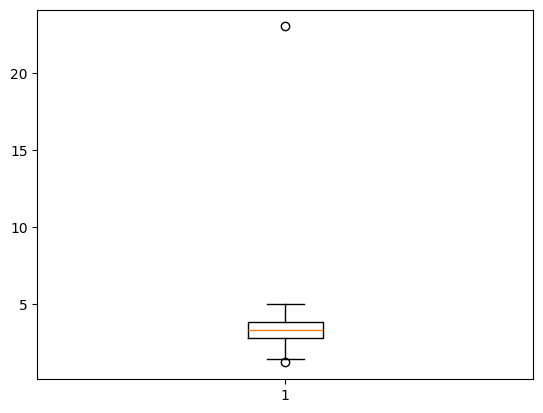

In [ ]:
# 개업률 이상치 발견
plt.boxplot(df['개업률'])

In [ ]:
# 23으로 오타인 것을 확인, 2.3으로 수정
df[df['개업률'] == 23]
df.loc[df['개업률'] == 23, '개업률'] = 2.3
df[df['개업률']==2.3]

,행정구역,연도_분기,개업률,폐업률,1년 생존율,5년 생존율,log인구,환산임대료,10년영업기간,30년영업기간,실업률,소비자심리지수(평균),소득분위,연도_분기_날짜,original_index,1년 생존율_차분,5년 생존율_차분,프랜차이즈비율
28,중구,2015-Q2,2.3,2.8,81.2,44.1,5.130977,190799,3.9,6.0,3.80,103.266667,7,2015-04-01,28,0.0,0.0,0.038420
184,중구,2016-Q4,2.3,2.3,79.8,42.2,5.128428,185204,3.6,6.0,3.20,97.666667,7,2016-10-01,184,0.0,0.0,0.040070
289,용산구,2017-Q4,2.3,2.3,80.3,43.0,5.388179,113751,3.3,5.6,3.20,112.000000,8,2017-10-01,289,0.0,0.0,0.055131
292,동대문구,2017-Q4,2.3,2.7,74.7,36.9,5.563494,79510,3.2,5.6,3.20,112.000000,7,2017-10-01,292,0.0,0.0,0.063059
315,용산구,2018-Q1,2.3,3.3,78.8,39.7,5.389894,112427,3.3,5.6,4.27,110.133333,8,2018-01-01,315,-1.5,-3.3,0.055280
318,동대문구,2018-Q1,2.3,3.4,72.6,36.0,5.562248,85854,3.2,5.6,4.27,110.133333,7,2018-01-01,318,-2.1,-0.9,0.063034
330,금천구,2018-Q1,2.3,3.5,74.2,38.3,5.403711,84702,3.1,5.3,4.27,110.133333,6,2018-01-01,330,-0.3,1.6,0.068792
331,영등포구,2018-Q1,2.3,3.6,75.3,36.7,5.606368,93736,3.1,5.4,4.27,110.133333,8,2018-01-01,331,0.7,1.7,0.073613
365,종로구,2018-Q3,2.3,3.1,80.5,44.2,5.212417,183329,3.3,6.2,3.77,101.066667,8,2018-07-01,365,0.0,0.0,0.056091
370,동대문구,2018-Q3,2.3,3.1,72.6,36.0,5.563601,100427,3.1,5.7,3.77,101.066667,7,2018-07-01,370,0.0,0.0,0.062480


In [ ]:
# 폰트 설치
!apt-get -qq install fonts-nanum
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 한글 폰트 적용
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

<ipython-input-154-5da524380aa1>:6: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-154-5da524380aa1>:6: UserWarning: Glyph 50629 (\N{HANGUL SYLLABLE EOB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-154-5da524380aa1>:6: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-154-5da524380aa1>:6: UserWarning: Glyph 54224 (\N{HANGUL SYLLABLE PYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-154-5da524380aa1>:6: UserWarning: Glyph 45380 (\N{HANGUL SYLLABLE NYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-154-5da524380aa1>:6: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-154-5da524380aa1>:6: UserWarning: Glyph 51316 (\N{HANGUL SYLLABLE JON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<

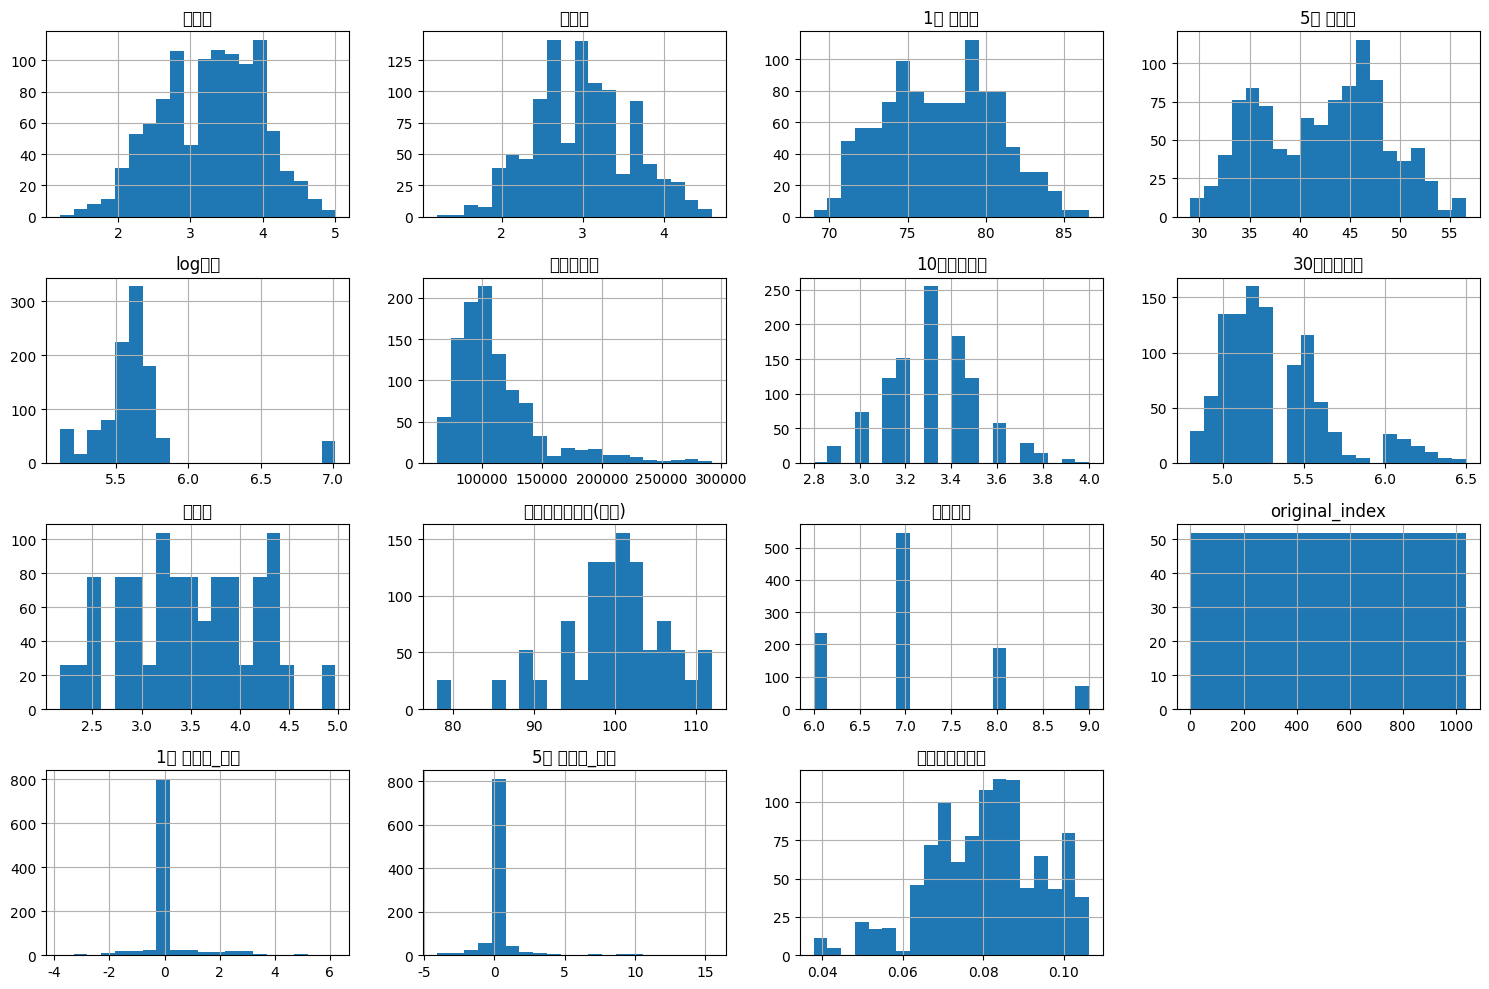

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols].hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

4. 폐업률간의 관계 시각화

/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:123: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  self._figure.tight_layout(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:123: UserWarning: Glyph 50629 (\N{HANGUL SYLLABLE EOB}) missing from font(s) DejaVu Sans.
  self._figure.tight_layout(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:123: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  self._figure.tight_layout(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:123: UserWarning: Glyph 54224 (\N{HANGUL SYLLABLE PYE}) missing from font(s) DejaVu Sans.
  self._figure.tight_layout(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:123: UserWarning: Glyph 45380 (\N{HANGUL SYLLABLE NYEON}) missing from font(s) DejaVu Sans.
  self._figure.tight_layout(*args, **kwargs)
/usr/local/lib/python3

/usr/local/lib/python3.11/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 50629 (\N{HANGUL SYLLABLE EOB}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 54224 (\N{HANGUL SYLLABLE PYE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 45380 (\N{HANGUL SYLLABLE NYEON}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG

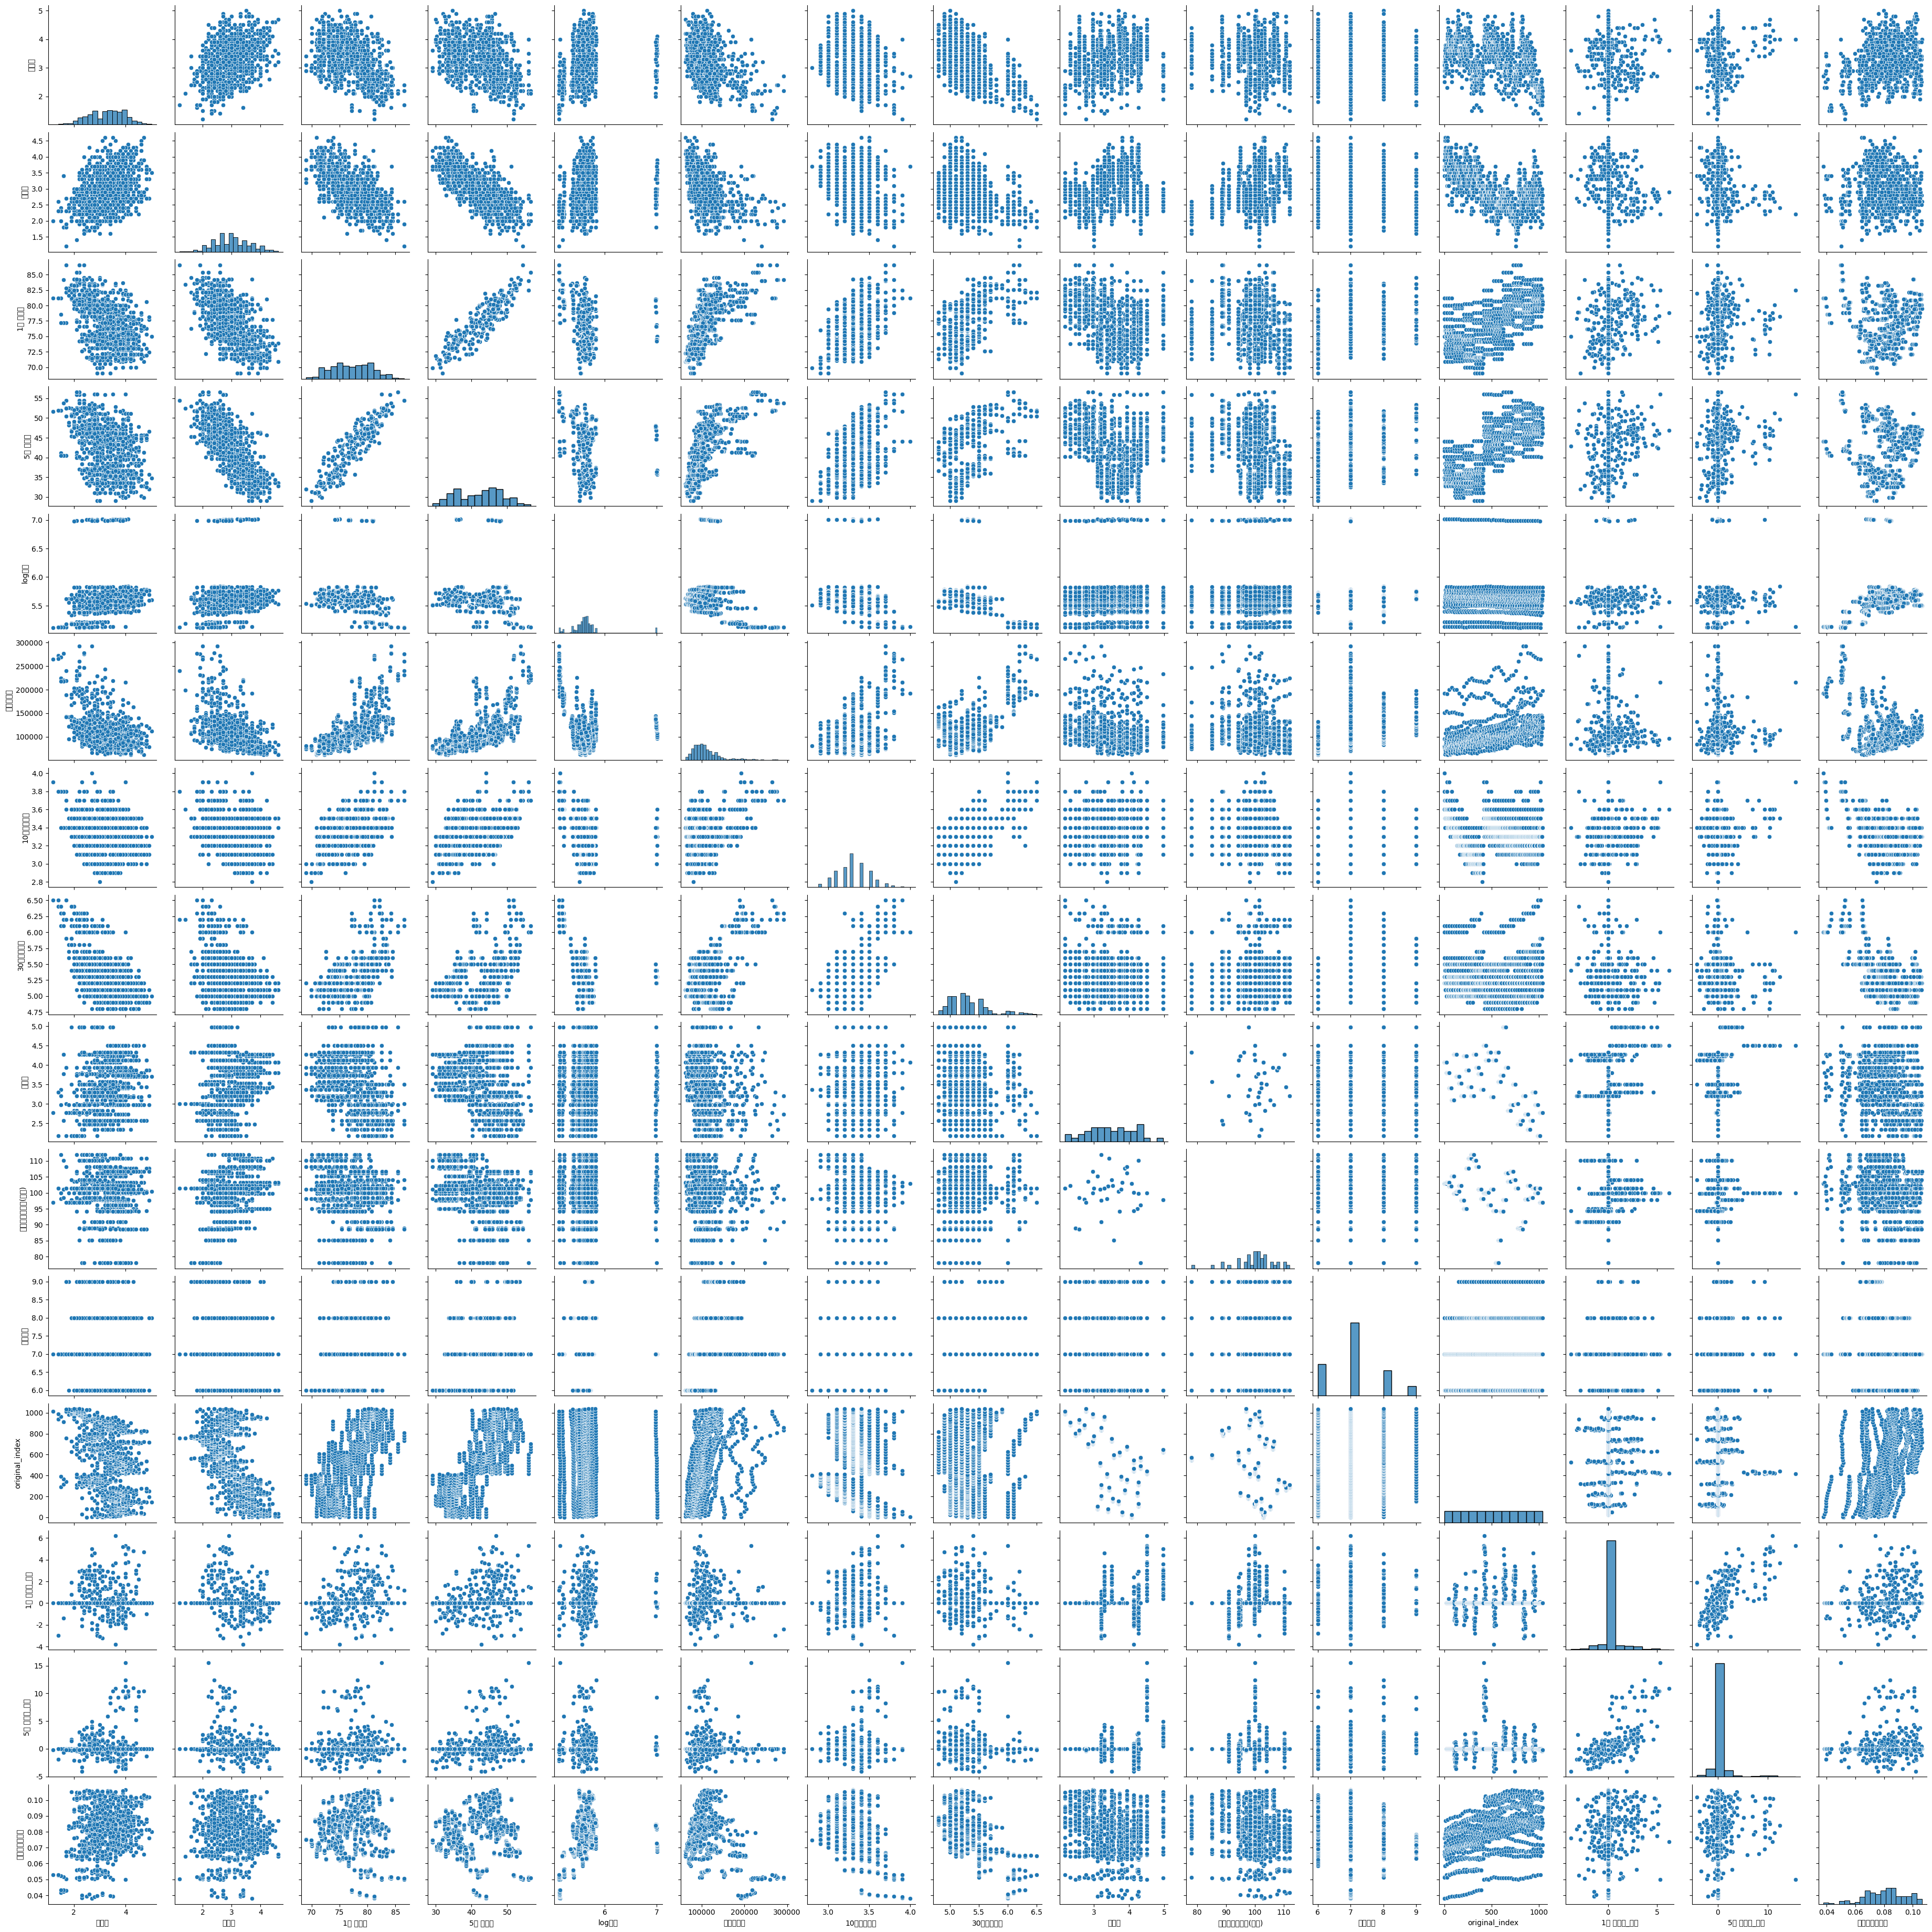

In [ ]:
sns.pairplot(df)

-> 시기별, 자치구별 데이터로 되어 있으므로 특정 행을 삭제하기 어려움
-> 일단 10년,30년 영업기간과 임대시세간의 관계를 어떻게 해결할 것인가 고민 필요

- 방법1: PCA 수행, '10년영업기간', '30년영업기간', '환산임대료'을 '영업_PCA1', '영업_PCA2'로 만듦.
-> 변수 해석이 어려워짐.

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
df1= df.copy()

# 상관 높은 변수만 추출
cols = ['10년영업기간', '30년영업기간', '환산임대료']
X = df1[cols]

# 표준화
X_scaled = StandardScaler().fit_transform(X)

# PCA 적용
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 결과 병합
df1['영업_PCA1'] = X_pca[:, 0]
df1['영업_PCA2'] = X_pca[:, 1]

# 원래 변수 제거
df1.drop(columns=cols, inplace=True)

In [ ]:
print(pca.explained_variance_ratio_)

[0.69854886 0.1935748 ]


- PCA1 (영업_PCA1): 전체 변동성(정보)의 약 69.85%
- PCA2 (영업_PCA2): 전체 변동성의 약 19.36%

- 두 성분의 총합: 약 89.21%
-> 즉, 원래의 세 변수인 10년영업기간, 30년영업기간, 환산임대료의 정보를 89.21% 수준으로 유지하면서
다중공선성 문제를 제거하고 변수 차원을 3 → 2로 축소한 것입니다.

-> **더 고민 필요 !!**

---

## [3] 정규화 및 표준화
정규화: 범위가 큰 값 (인구(raw), 환산임대료, 실업률, 소비자심리지수(평균))

표준화: 비율 값이나 퍼센트 값 (개업률, 폐업률, 1년 생존율, 3년 생존율, 5년 생존율, 10년영업기간, 30년영업기간)
-> 고정회귀모형은 표준화가 적절함.

In [ ]:
'''
df2 = df.copy()
from sklearn.preprocessing import StandardScaler, MinMaxScaler
normalize_cols = ['환산임대료', '실업률', '소비자심리지수(평균)']
standardize_cols = ['개업률', '폐업률', '1년 생존율', '5년 생존율', '10년영업기간', '30년영업기간']

minmax_scaler = MinMaxScaler()
standard_scaler = StandardScaler()

df2[normalize_cols] = minmax_scaler.fit_transform(df2[normalize_cols])
df2[standardize_cols] = standard_scaler.fit_transform(df2[standardize_cols])
df2.head()
'''

,행정구역,연도_분기,개업률,폐업률,1년 생존율,5년 생존율,log인구,환산임대료,10년영업기간,30년영업기간,실업률,소비자심리지수(평균),프랜차이즈비율
0,서울시 전체,2015-Q1,-0.205034,1.502138,-0.599783,-0.866426,7.015740,0.150950,1.494381,-0.031013,0.678571,0.734314,0.067481
1,종로구,2015-Q1,-0.858796,0.672844,0.807332,-0.001094,5.218115,0.387711,2.523282,2.403180,0.678571,0.734314,0.051670
2,중구,2015-Q1,-0.640875,1.170420,1.145040,0.303375,5.133740,0.564024,3.552184,2.098906,0.678571,0.734314,0.037913
3,용산구,2015-Q1,-0.422955,1.004562,0.469625,-0.081217,5.397945,0.144740,2.523282,0.577536,0.678571,0.734314,0.051237
4,성동구,2015-Q1,-0.096074,1.170420,0.188202,-0.321587,5.482555,0.063510,2.008831,0.881810,0.678571,0.734314,0.065794


- 표준화 적용

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 표준화할 컬럼들
standardize_cols = [
    '개업률',
    '폐업률',
    '1년 생존율',
    '5년 생존율',
    'log인구',
    '환산임대료',
    '10년영업기간',
    '30년영업기간',
    '실업률',
    '소비자심리지수(평균)',
    '소득분위',
    '1년 생존율_차분',
    '5년 생존율_차분',
    '프랜차이즈비율'
]

# 데이터 표준화
standard_scaler = StandardScaler()
df2 = pd.DataFrame(standard_scaler.fit_transform(df[standardize_cols]), columns=standardize_cols)

# 결과 확인
df2.head()

,개업률,폐업률,1년 생존율,5년 생존율,log인구,환산임대료,10년영업기간,30년영업기간,실업률,소비자심리지수(평균),소득분위,1년 생존율_차분,5년 생존율_차분,프랜차이즈비율
0,-0.205034,1.502138,-0.599783,-0.866426,4.381544,-0.413165,1.494381,-0.031013,0.899262,0.465853,-0.108146,-0.155411,-0.159551,-0.948041
1,-0.858796,0.672844,0.807332,-0.001094,-1.296470,1.084126,2.523282,2.403180,0.899262,0.465853,-0.108146,-0.155411,-0.159551,-2.077364
2,-0.640875,1.170420,1.145040,0.303375,-1.562979,2.199138,3.552184,2.098906,0.899262,0.465853,-0.108146,-0.155411,-0.159551,-3.059932
3,-0.422955,1.004562,0.469625,-0.081217,-0.728456,-0.452434,2.523282,0.577536,0.899262,0.465853,1.114372,-0.155411,-0.159551,-2.108237
4,-0.096074,1.170420,0.188202,-0.321587,-0.461205,-0.966140,2.008831,0.881810,0.899262,0.465853,-0.108146,-0.155411,-0.159551,-1.068564


---
## [3] 논문 목차
1. 기초통계
- 상관행렬: 주요 변수 간 선형관계의 강도를 파악
- VIF(분산팽창인자): 변수별 VIF를 계산해 다중공선성이 심각한지(일반적으로 VIF > 10) 확인


2. 모형 선택 검정
  
  (1) F-검정 (poolability test)
  - 목적: Pooled OLS(=공통계수) vs 개체별(자치구) 고정효과 모형
  - Stata의 xttest0(pF test)나 R의 plm::pFtest() 사용

  (2)Hausman 검정
  - 목적: 고정효과(FE) vs 확률효과(RE) 중 일관성 비교
  - H₀: RE 일관성 유지 → p-value < 0.05면 FE 선택

  (3) 1계 자기상관 검정
  - Wooldridge test: 패널 FE/RE 모형에서 1차 자기상관 존재 여부
  - H₀: 자기상관 없음 → plm::pwartest() 또는 Stata xtserial
  - 해결: 자기상관이 확인되면 GLS (xtregar) 또는 차분 모형(FD estimator) 고려

  (4) 이분산성 검정
  - Modified Wald test for groupwise heteroskedasticity in FE models
  - Stata xttest3, R plm::bptest(..., group = "group") 등


3. 고정효과 회귀 모형 추정
- Demeaning: 각 변수에서 개체별 평균(자치구별 평균)을 차감한 뒤 OLS 수행


4. 결과 해석
- βk (지역변수): 각 자치구 특성(예: 임대료, 프랜차이즈비율)이 폐업률에 미치는 한 단위 변화 효과
- βs (거시변수): 실업률·소비자심리지수 같은 경기변수가 폐업률에 미치는 동시(혹은 지연)효과
- 통계적 유의성: p-value,
- 모형설명력 비교: within R² 변화, AIC/BIC 값 비교


5. Robustness Checks (강건성 검토)
- 논문에서는 통상 다음 추가 분석으로 결과의 안정성을 확인
- 대체 사양: Random Effects나 Pooled OLS, First-Difference 추정치 비교
- 지연효과 포함: 거시·상권변수의 1분기(lag = 1) 지연항 추가
- 서브샘플: 강남권 vs 도심 외곽, 고임대료 vs 저임대료 등으로 분석 반복


- 참고 문헌:
https://www-dbpia-co-kr-ssl.access.ewha.ac.kr/journal/articleDetail?nodeId=NODE10583689
https://www-dbpia-co-kr-ssl.access.ewha.ac.kr/journal/articleDetail?nodeId=NODE10558908
-> 공통적으로 하우스만 검정, 강건성 검토, Pooled OLS,RE,FE 중 어떤 모델을 사용해야 할지 검정 등등